In [1]:
'''Code to test the SAVE_ALL functionality of the AQUA model'''

'Code to test the SAVE_ALL functionality of the AQUA model'

In [2]:
import aqua
from aqua.batchAQUA_general import *
from aqua.stimulus import *
from aqua.plotting_functions import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
arr = np.array([[[0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4]],
                 [[0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4]],
                 [[0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4],
                 [0, 1, 2, 3, 4]]])

new_vec = np.array([[5, 5, 5], 
                    [6, 6, 6],
                    [7, 7, 7]])

print(arr.shape)
print(arr)
print(new_vec.shape)
print('- - - -')
new_arr = np.roll(arr, -1, axis = 2)
print(new_arr)
new_arr[:,:, -1] = new_vec
print('- - APPENDED - -')
print(new_arr)



(3, 3, 5)
[[[0 1 2 3 4]
  [0 1 2 3 4]
  [0 1 2 3 4]]

 [[0 1 2 3 4]
  [0 1 2 3 4]
  [0 1 2 3 4]]

 [[0 1 2 3 4]
  [0 1 2 3 4]
  [0 1 2 3 4]]]
(3, 3)
- - - -
[[[1 2 3 4 0]
  [1 2 3 4 0]
  [1 2 3 4 0]]

 [[1 2 3 4 0]
  [1 2 3 4 0]
  [1 2 3 4 0]]

 [[1 2 3 4 0]
  [1 2 3 4 0]
  [1 2 3 4 0]]]
- - APPENDED - -
[[[1 2 3 4 5]
  [1 2 3 4 5]
  [1 2 3 4 5]]

 [[1 2 3 4 6]
  [1 2 3 4 6]
  [1 2 3 4 6]]

 [[1 2 3 4 7]
  [1 2 3 4 7]
  [1 2 3 4 7]]]


In [7]:
T = 300 # ms
dt = 0.01
N_iter = int(T/dt)

# use the RS model
FS0 = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': 100., 'tau': 0.}   # subcritical Andronov-Hopf (class 2)

FS1 = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': 120., 'tau': 0.}   # subcritical Andronov-Hopf (class 2)

FS2 = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0.2, 'f': 130., 'tau': 0.}   # subcritical Andronov-Hopf (class 2)

param_df = pd.DataFrame([FS0, FS1, FS2])
N_neurons = len(param_df)

x_start = np.full((N_neurons, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(N_neurons)

I_inj = 100*np.ones((N_neurons, N_iter))

# create batch
batch = batchAQUA(param_df)
batch.Initialise(x_start, t_start)

X, t, spikes1 = batch.update_batch(dt, N_iter, I_inj)

# Re-initialise and run
batch.Initialise(x_start, t_start)
spikes2 = batch.update_batch(dt, N_iter, I_inj, SAVE_ALL = False)


100%|██████████| 29999/29999 [00:04<00:00, 7155.75it/s]


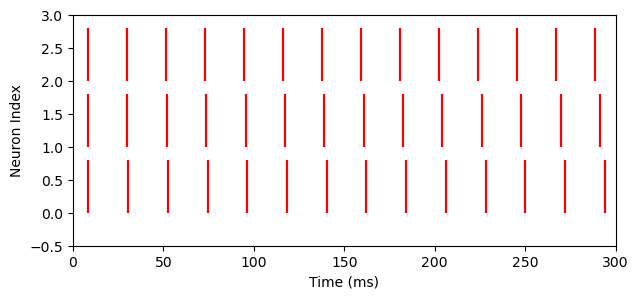

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (7, 3))

fig, ax = plot_raster(spikes1, T, ax = ax, color = 'black')
fig, ax = plot_raster(spikes2, T, ax = ax, color = 'red')

In [9]:
print(spikes1)
print('==========')
print(spikes2)

[[  8.45  30.32  52.33  74.38  96.43 118.39 140.28 162.23 184.25 206.08
  228.1  250.02 272.08 294.08]
 [  8.45  30.05  51.74  73.62  95.49 117.19 138.96 160.8  182.38 204.2
  226.03 247.88 269.67 291.51]
 [  8.45  29.91  51.45  73.15  94.65 116.26 137.69 159.42 180.93 202.51
  223.92 245.44 266.9  288.44]]
[[  8.45  30.32  52.33  74.38  96.43 118.39 140.28 162.23 184.25 206.08
  228.1  250.02 272.08 294.08]
 [  8.45  30.05  51.74  73.62  95.49 117.19 138.96 160.8  182.38 204.2
  226.03 247.88 269.67 291.51]
 [  8.45  29.91  51.45  73.15  94.65 116.26 137.69 159.42 180.93 202.51
  223.92 245.44 266.9  288.44]]
